In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
with open(r"D:\Test\Python\Deep Learning\micrograd\files\names.txt","r") as f:
    words = f.read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [3]:
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
vocab_size

27

In [4]:
block_size = 8

def build_dataset(words):
    X,Y = [],[]

    for w in words:
        context = [0] * block_size

        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [5]:
for x,y in zip(Xtr[:20],Ytr[:20]):
    print("".join(itos[i.item()] for i in x), "-->",itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [6]:
class Linear:
    def __init__(self,fan_in,fan_out,bias=True):
        self.weights = torch.randn((fan_in,fan_out)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self,x):
        self.out = x @ self.weights
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weights] + ([] if self.bias is None else [self.bias])

class BatchNorm1D:
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self,x):
            # calculate forward pass
            if self.training:
                if x.ndim == 2:
                    dim = 0
                elif x.ndim == 3:
                    dim = (0,1)
                xmean = x.mean(dim,keepdim=True)
                xvar = x.var(dim,keepdim=True,unbiased=True)
    
            else:
                xmean = self.running_mean
                xvar = self.running_var
    
            xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize unit variance 
            self.out = self.gamma * xhat + self.beta # scale and shift
    
            if self.training:
                with torch.no_grad():
                    # Update the bufferes using Exponential Moving Average (EMA) with momentum
                    self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                    self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
            return self.out
        
    def parameters(self):
        return [self.gamma,self.beta]

class Tanh:
    def __call__(self,x):
          self.out = torch.tanh(x)
          return self.out

    def parameters(self):
         return []


class Embedding:
    def __init__(self,n_embd,embd_dim):
          self.weights = torch.randn((n_embd,embd_dim))

    def __call__(self,x):
         self.out = self.weights[x]
         return self.out

    def parameters(self):
        return [self.weights]

class Flatten:
    def __init__(self,n):
         self.n = n

    def __call__(self,x):
         B,T,C = x.shape

         x = x.view(B,T//self.n,C*self.n)    
         if x.shape[1]==1:
            x = x.squeeze()

         self.out = x
         return self.out
         
    def parameters(self):
         return []


class Sequential:
    def __init__(self,layers):
          self.layers = layers

    def __call__(self,x):
         for layer in self.layers:
              x = layer(x)
         self.out = x
         return self.out

    def parameters(self):
         return [p for layer in self.layers for p in layer.parameters()]


In [22]:
n_embd = 32 # the dimensionality of the character embedding vectors
n_hidden = 256 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

# C = torch.randn((vocab_size,n_embd),generator=g)
model = Sequential([
    Embedding(vocab_size,n_embd),
    Flatten(2), Linear(n_embd * 2,n_hidden),BatchNorm1D(n_hidden),Tanh(),
    Flatten(2), Linear(n_hidden * 2,n_hidden),BatchNorm1D(n_hidden),Tanh(),
    Flatten(2), Linear(n_hidden * 2,n_hidden),BatchNorm1D(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size), 
])

# with torch.no_grad():
#     layers[-1].weights *= 0.1 # last layer make less confident

# parameters =  [p for layer in layers for p in layer.parameters()]
parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True      

288635


In [23]:
ix = torch.randint(0,Xtr.shape[0],(4,))
Xb,Yb = Xtr[ix],Ytr[ix]
logits = model(Xb)
logits.shape

torch.Size([4, 27])

In [24]:
for layer in model.layers:
    print(f"{layer.__class__.__name__} : {tuple(layer.out.shape)}")

Embedding : (4, 8, 32)
Flatten : (4, 4, 64)
Linear : (4, 4, 256)
BatchNorm1D : (4, 4, 256)
Tanh : (4, 4, 256)
Flatten : (4, 2, 512)
Linear : (4, 2, 256)
BatchNorm1D : (4, 2, 256)
Tanh : (4, 2, 256)
Flatten : (4, 512)
Linear : (4, 256)
BatchNorm1D : (4, 256)
Tanh : (4, 256)
Linear : (4, 27)


In [25]:
max_steps = 5000
batch_size = 64
lossi = []

for i in range(max_steps):

    # mini batch construct
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb = Xtr[ix],Ytr[ix] #batch X,Y

    # emb = C[Xb] 
    # x = emb.view(emb.shape[0],-1)

    # forward pass
    # x = Xb
    # for layer in layers:
    #     x = layer(x)
    logits = model(Xb)
    loss = F.cross_entropy(logits,Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.05 if i < 100000 else 0.01 # step learing rate decay
    for p in parameters:
        p.data +=  -lr*p.grad

    # if i % 10000 == 0: 
    if i % 1000 == 0: 
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())

    
    

      0/   5000: 3.6122
   1000/   5000: 2.0164
   2000/   5000: 1.9612
   3000/   5000: 2.3199
   4000/   5000: 2.2435


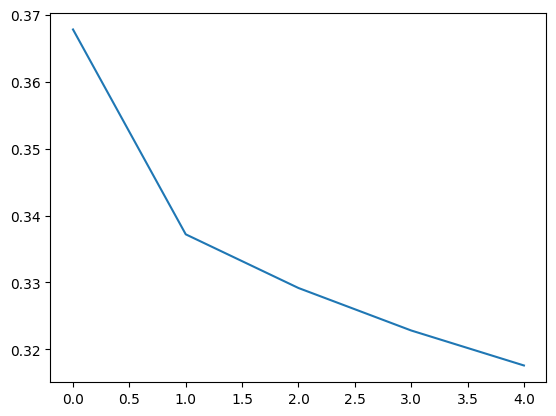

In [26]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [27]:
for layer in model.layers: # set training as false to evaluate the trained neural networks for batchnorm layers
    layer.training = False

In [28]:
torch.no_grad()
def split_loss(split):
    X,y = {
        "train":(Xtr,Ytr),
        "val":(Xdev,Ydev),
        "test":(Xte,Yte),
    }[split]

    # emb = C[X]
    # embcat = emb.view(emb.shape[0],-1)
    # for layer in layers:
    #     x = layer(embcat)
    
    logits = model(X)
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

split_loss('train')
split_loss('val')

train 2.0792737007141113
val 2.122300148010254


train 2.087792158126831
val 2.1352570056915283